# BiomedCLIP + Qwen2.5 Medical VQA — Demo Inference

**Notebook demo độc lập** — Load checkpoint đã fine-tune và chạy inference với ảnh y tế.

```
Cấu trúc checkpoint (từ lúc train):
  checkpoints/
    biomedclip_qwen_slake/       ← hoặc biomedclip_qwen_vqarad
      checkpoint_best/
        lora_adapter/            ← LoRA weights của Qwen2.5
        projector.pt             ← MLP Projector weights
        tokenizer/               ← Qwen2.5 tokenizer
        vision_encoder.pt        ← (chỉ có nếu BIOMEDCLIP_FREEZE != 'full')
        optimizer.pt
        scheduler.pt
      training_state.json
```

**Architecture:**
```
Image ──► BiomedCLIP Vision Encoder (frozen) ──► image_feat [B, 512]
                                                        │
                                              MLP Projector (512→1024→896)
                                                        │
Question ──► Qwen2.5-0.5B Tokenizer ──► [visual_token, text_tokens] ──► Qwen2.5-0.5B ──► Answer
```

**Luồng sử dụng:**
1. Cài thư viện (Cell 1)
2. Config đường dẫn checkpoint (Cell 2)
3. Định nghĩa model classes (Cell 3)
4. Load model từ checkpoint (Cell 4)
5. Predict với ảnh của bạn (Cell 5 trở đi)

## 📦 Cell 1: Cài đặt thư viện

In [2]:
!pip install -q transformers accelerate pillow peft bitsandbytes
!pip install -q open_clip_torch huggingface_hub
!pip install -q rouge-score sentence-transformers nltk requests
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
✅ Done!


## ⚙️ Cell 2: Config — chỉnh tại đây

In [3]:
# ============================================================
#  Copy checkpoint từ Kaggle Models về working dir
#  Chạy cell này trước Cell 4 khi resume
# ============================================================
import shutil, os

src = '/kaggle/input/models/bonguyen2508/biomedclip-qwen-slake/transformers/default/1/checkpoints'
dst = '/kaggle/working/checkpoints'

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print('✅ Copied checkpoints từ Models')
else:
    print('✅ Checkpoints đã có sẵn')

✅ Copied checkpoints từ Models


In [5]:
import torch, json, re
from pathlib import Path
from collections import Counter

# ── HuggingFace token (bắt buộc để tải Qwen2.5 base model) ──────────
# Cách 1: Dùng Kaggle Secrets (nếu chạy trên Kaggle)
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("NLP")
    print('✅ HF Token loaded từ Kaggle Secrets')
except Exception:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('NLP')
        print('✅ HF Token loaded từ Colab Secrets')
    except Exception:
        # Cách 2: Điền thẳng (chạy local)
        HF_TOKEN = 'hf_...'   # ← thay token của bạn tại đây
        print('⚠️  Dùng HF_TOKEN hardcoded — nhớ xoá trước khi share notebook')

# ── Đường dẫn checkpoint ────────────────────────────────────
# Thay bằng đường dẫn thực tế đến checkpoint đã train
CHECKPOINT_DIR  = '/kaggle/working/checkpoints'   # thư mục gốc
EXPERIMENT_NAME = 'biomedclip_qwen_slake'         # tên experiment (khớp với lúc train)

# Chọn checkpoint nào để load:
#   'best'           → checkpoint có val_f1 cao nhất
#   'last'           → checkpoint cuối cùng
#   3                → epoch cụ thể (ví dụ epoch 3)
#   '/full/path/...' → đường dẫn tuyệt đối đến folder checkpoint
LOAD_FROM = 'best'

# ── Model config (phải khớp với lúc train) ──────────────────
BIOMEDCLIP_MODEL = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
BIOMEDCLIP_FREEZE = 'full'   # 'full' | 'last2' | 'none' — khớp với lúc train
IMAGE_SIZE       = 224
IMAGE_FEAT_DIM   = 512       # output dim BiomedCLIP vision encoder
PROJECTOR_HIDDEN = 1024

LLM_MODEL   = 'Qwen/Qwen2.5-0.5B-Instruct'   # phải đúng model đã train
LLM_HIDDEN  = 896    # 0.5B=896, 1.5B=1536
MAX_NEW_TOKENS = 32  # độ dài tối đa câu trả lời

# ── LoRA config (khớp với lúc train) ────────────────────────
USE_LORA     = True
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'v_proj', 'k_proj', 'o_proj']

# ── Dataset (để evaluate nếu cần) ───────────────────────────
DATASET_NAME = 'mdwiratathya/SLAKE-vqa-english'   # dataset đã train
DATASET_NAME = 'flaviagiammarino/vqa-rad'
TRAIN_SPLIT  = 'train'
TEST_SPLIT   = 'test'
Q_COL        = 'question'
A_COL        = 'answer'

# ── Device ──────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    USE_4BIT = vram < 20
    print(f'GPU  : {torch.cuda.get_device_name(0)} ({vram:.1f} GB)')
else:
    USE_4BIT = False
    print('⚠️  Không có GPU — inference sẽ rất chậm trên CPU')

print(f'Device : {DEVICE} | 4-bit : {USE_4BIT}')
print(f'Checkpoint dir : {CHECKPOINT_DIR}/{EXPERIMENT_NAME}')
print(f'Load from      : {LOAD_FROM}')

✅ HF Token loaded từ Kaggle Secrets
GPU  : Tesla T4 (15.6 GB)
Device : cuda | 4-bit : True
Checkpoint dir : /kaggle/working/checkpoints/biomedclip_qwen_slake
Load from      : best


## 🗂️ Cell 3: Checkpoint Manager (giống lúc train)

In [6]:
class CheckpointManager:
    """Quản lý checkpoint — giống hệt class trong notebook train."""
    def __init__(self, base_dir, exp_name):
        self.exp_dir    = Path(base_dir) / exp_name
        self.state_file = self.exp_dir / 'training_state.json'

    def load(self, which='best'):
        state = self._load_state()
        if not state:
            raise FileNotFoundError(
                f'Không tìm thấy training_state.json trong {self.exp_dir}\n'
                f'Hãy chắc chắn CHECKPOINT_DIR và EXPERIMENT_NAME đúng.'
            )
        if which == 'best':
            path = self.exp_dir / 'checkpoint_best'
            if not path.exists():
                raise FileNotFoundError(f'Không tìm thấy checkpoint_best tại {path}')
            print(f'📂 Sẽ load: {path} (epoch={state.get("best_checkpoint","?")})')
            return path, state
        elif which == 'last':
            name = state.get('last_checkpoint')
        elif isinstance(which, int):
            name = f'checkpoint_epoch{which}'
        elif Path(which).is_absolute():
            path = Path(which)
            if not path.exists():
                raise FileNotFoundError(f'Không tìm thấy: {path}')
            return path, state
        else:
            name = which

        path = self.exp_dir / name
        if not path.exists():
            raise FileNotFoundError(
                f'Không tìm thấy checkpoint: {path}\n'
                f'Các checkpoint hiện có: {list(self.exp_dir.glob("checkpoint_*"))}'
            )
        print(f'📂 Sẽ load: {path}')
        return path, state

    def list(self):
        state = self._load_state()
        if not state:
            print(f'❌ Không tìm thấy checkpoint nào trong: {self.exp_dir}')
            return
        print(f'\n📋 Experiment : {self.exp_dir.name}')
        print(f'   Dir         : {self.exp_dir}')
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        history = {h['epoch']: h for h in state.get('history', [])}
        for c in ckpts:
            ep  = int(c.name.replace('checkpoint_epoch', ''))
            h   = history.get(ep, {})
            tag = ' ← LAST' if c.name == state.get('last_checkpoint') else ''
            ls  = f" loss={h['train_loss']:.4f}" if 'train_loss' in h else ''
            fs  = f" f1={h['val_f1']:.2f}%"      if 'val_f1'    in h else ''
            print(f'   {c.name}{ls}{fs}{tag}')
        best = self.exp_dir / 'checkpoint_best'
        if best.exists():
            print(f'   checkpoint_best → {state.get("best_checkpoint","?")} '
                  f'(F1={state.get("best_f1","?")}%)')
        print(f'\n   LLM model  : {state.get("llm_model", "?")}')
        print(f'   BiomedCLIP : {state.get("biomedclip_model", "?")}')
        print(f'   Dataset    : {state.get("dataset", "?")}')

    def _load_state(self):
        return json.load(open(self.state_file)) if self.state_file.exists() else {}


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR, EXPERIMENT_NAME)
print('📋 Danh sách checkpoint:')
ckpt_mgr.list()

📋 Danh sách checkpoint:

📋 Experiment : biomedclip_qwen_slake
   Dir         : /kaggle/working/checkpoints/biomedclip_qwen_slake
   checkpoint_epoch4 loss=0.2033 f1=82.18%
   checkpoint_epoch5 loss=0.1431 f1=84.59%
   checkpoint_epoch6 loss=0.1025 f1=85.77% ← LAST
   checkpoint_best → checkpoint_epoch6 (F1=85.77%)

   LLM model  : Qwen/Qwen2.5-0.5B-Instruct
   BiomedCLIP : hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
   Dataset    : mdwiratathya/SLAKE-vqa-english


## 🧱 Cell 4: Định nghĩa Model Classes

> Phải định nghĩa lại các class giống hệt lúc train để load weights đúng

In [7]:
import torch
import torch.nn as nn
import open_clip
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from huggingface_hub import login

login(token=HF_TOKEN)


# ============================================================
# 1. MLP Projector: BiomedCLIP (512d) → LLM hidden (896d)
# ============================================================
class MLPProjector(nn.Module):
    """
    2-layer MLP bridge:
      image_feat [B, 512] → visual_token_emb [B, 1, LLM_HIDDEN]
    """
    def __init__(self, in_dim=512, hidden_dim=1024, out_dim=896):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
            nn.LayerNorm(out_dim)
        )

    def forward(self, x):              # x: [B, 512]
        return self.net(x).unsqueeze(1)  # → [B, 1, out_dim]


# ============================================================
# 2. BiomedCLIP Vision Encoder wrapper
# ============================================================
class BiomedCLIPVisionEncoder(nn.Module):
    """
    Wrap BiomedCLIP để chỉ dùng phần vision encoder.
    Output: [B, 512] — CLS token embedding từ ViT-B/16
    """
    def __init__(self, model_name=BIOMEDCLIP_MODEL, freeze=BIOMEDCLIP_FREEZE):
        super().__init__()
        print(f'📥 Loading BiomedCLIP vision encoder...')
        clip_model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, precision='fp16' if torch.cuda.is_available() else 'fp32'
        )
        self.visual = clip_model.visual
        del clip_model
        self._apply_freeze(freeze)
        trainable = sum(p.numel() for p in self.visual.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.visual.parameters())
        print(f'   BiomedCLIP freeze={freeze}: {trainable:,}/{total:,} params trainable')

    def _apply_freeze(self, freeze):
        if freeze == 'full':
            for p in self.visual.parameters():
                p.requires_grad = False
        elif freeze == 'last2':
            for p in self.visual.parameters():
                p.requires_grad = False
            for p in self.visual.transformer.resblocks[-2:].parameters():
                p.requires_grad = True
            if hasattr(self.visual, 'ln_post'):
                for p in self.visual.ln_post.parameters():
                    p.requires_grad = True
            if hasattr(self.visual, 'proj') and self.visual.proj is not None:
                self.visual.proj.requires_grad = True

    def forward(self, pixel_values):
        feat = self.visual(pixel_values)   # [B, 512]
        return feat.float()                # upcast về fp32


# ============================================================
# 3. Main Model: BiomedCLIP + Projector + Qwen2.5
# ============================================================
class BiomedCLIPQwenVQA(nn.Module):
    """
    Medical VQA model:
      BiomedCLIP Vision Encoder → MLP Projector → Qwen2.5 LLM
    """
    def __init__(self):
        super().__init__()
        self.vision_encoder = BiomedCLIPVisionEncoder()
        self.projector = MLPProjector(
            in_dim=IMAGE_FEAT_DIM,
            hidden_dim=PROJECTOR_HIDDEN,
            out_dim=LLM_HIDDEN
        )
        print(f'📥 Loading LLM: {LLM_MODEL}...')
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4'
        ) if USE_4BIT else None

        llm_base = AutoModelForCausalLM.from_pretrained(
            LLM_MODEL,
            quantization_config=bnb_config,
            device_map='auto',
            torch_dtype=torch.bfloat16,
            token=HF_TOKEN
        )
        if USE_LORA:
            if USE_4BIT:
                llm_base = prepare_model_for_kbit_training(llm_base)
            lora_cfg = LoraConfig(
                r=LORA_R, lora_alpha=LORA_ALPHA,
                lora_dropout=LORA_DROPOUT,
                target_modules=LORA_TARGETS,
                bias='none',
                task_type=TaskType.CAUSAL_LM
            )
            self.llm = get_peft_model(llm_base, lora_cfg)
        else:
            self.llm = llm_base

    def forward(self, pixel_values, input_ids, attention_mask, labels=None):
        image_feat   = self.vision_encoder(pixel_values)           # [B, 512]
        visual_token = self.projector(image_feat)                  # [B, 1, LLM_HIDDEN]
        text_emb     = self.llm.get_input_embeddings()(input_ids)  # [B, L, LLM_HIDDEN]
        combined_emb  = torch.cat([visual_token, text_emb], dim=1)
        visual_mask   = torch.ones(attention_mask.shape[0], 1,
                                   device=attention_mask.device, dtype=attention_mask.dtype)
        combined_mask = torch.cat([visual_mask, attention_mask], dim=1)
        if labels is not None:
            visual_label    = torch.full((labels.shape[0], 1), -100,
                                         device=labels.device, dtype=labels.dtype)
            combined_labels = torch.cat([visual_label, labels], dim=1)
        else:
            combined_labels = None
        return self.llm(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            labels=combined_labels
        )


print('✅ Model classes defined')

✅ Model classes defined


## 🧠 Cell 5: Load Model từ Checkpoint

In [8]:
from transformers import AutoTokenizer

# ── Load checkpoint info ─────────────────────────────────────
ckpt_path, ckpt_state = ckpt_mgr.load(LOAD_FROM)

print(f'\n📦 LLM model   : {ckpt_state.get("llm_model", LLM_MODEL)}')
print(f'   BiomedCLIP  : {ckpt_state.get("biomedclip_model", BIOMEDCLIP_MODEL)}')
print(f'   LoRA adapter: {ckpt_path / "lora_adapter"}')
print(f'   Projector   : {ckpt_path / "projector.pt"}')
print(f'   Tokenizer   : {ckpt_path / "tokenizer"}')

# ── Load tokenizer ────────────────────────────────────────────
print('\n⏳ Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(ckpt_path / 'tokenizer')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print('✅ Tokenizer loaded')

# ── Build model (vision encoder + projector + Qwen2.5 base + LoRA) ──
print('\n⏳ Building model (có thể mất 1-2 phút)...')
model = BiomedCLIPQwenVQA()
model.vision_encoder = model.vision_encoder.to(DEVICE)
model.projector      = model.projector.to(DEVICE)
print('✅ Base model built')

# ── Restore Projector weights ────────────────────────────────
model.projector.load_state_dict(
    torch.load(ckpt_path / 'projector.pt', map_location=DEVICE)
)
print('✅ Projector weights restored')

# ── Restore Vision Encoder (chỉ khi BIOMEDCLIP_FREEZE != 'full') ─────
ve_path = ckpt_path / 'vision_encoder.pt'
if ve_path.exists():
    model.vision_encoder.visual.load_state_dict(
        torch.load(ve_path, map_location=DEVICE)
    )
    print('✅ Vision encoder weights restored')
else:
    print('ℹ️  vision_encoder.pt không có (BiomedCLIP freeze=full — dùng weights gốc)')

# ── Restore LoRA adapter của Qwen2.5 ────────────────────────
model.llm.load_adapter(ckpt_path / 'lora_adapter', adapter_name='default')
print('✅ LoRA adapter restored')

# ── Lấy preprocess transform từ BiomedCLIP ───────────────────
biomedclip_transform = model.vision_encoder.preprocess

model.eval()
print(f'\n✅ Model sẵn sàng!')
print(f'   Checkpoint : {ckpt_path.name}')
print(f'   Best F1    : {ckpt_state.get("best_f1", "N/A")}')
print(f'   Dataset    : {ckpt_state.get("dataset", "N/A")}')

📂 Sẽ load: /kaggle/working/checkpoints/biomedclip_qwen_slake/checkpoint_best (epoch=checkpoint_epoch6)

📦 LLM model   : Qwen/Qwen2.5-0.5B-Instruct
   BiomedCLIP  : hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
   LoRA adapter: /kaggle/working/checkpoints/biomedclip_qwen_slake/checkpoint_best/lora_adapter
   Projector   : /kaggle/working/checkpoints/biomedclip_qwen_slake/checkpoint_best/projector.pt
   Tokenizer   : /kaggle/working/checkpoints/biomedclip_qwen_slake/checkpoint_best/tokenizer

⏳ Loading tokenizer...
✅ Tokenizer loaded

⏳ Building model (có thể mất 1-2 phút)...
📥 Loading BiomedCLIP vision encoder...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

   BiomedCLIP freeze=full: 0/86,191,872 params trainable
📥 Loading LLM: Qwen/Qwen2.5-0.5B-Instruct...


...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Base model built
✅ Projector weights restored
ℹ️  vision_encoder.pt không có (BiomedCLIP freeze=full — dùng weights gốc)
✅ LoRA adapter restored

✅ Model sẵn sàng!
   Checkpoint : checkpoint_best
   Best F1    : 85.77
   Dataset    : mdwiratathya/SLAKE-vqa-english


## 🖼️ Cell 6: Hàm xử lý ảnh + Predict

> Tiền xử lý ảnh dùng đúng `biomedclip_transform` của BiomedCLIP — **không** tự normalize thủ công

In [9]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt


def load_image(image_input):
    if isinstance(image_input, Image.Image):
        return image_input
    if isinstance(image_input, bytes):
        return Image.open(BytesIO(image_input))
    if isinstance(image_input, str):
        if image_input.startswith('http://') or image_input.startswith('https://'):
            response = requests.get(image_input, timeout=10)
            response.raise_for_status()
            return Image.open(BytesIO(response.content))
        else:
            return Image.open(image_input)
    raise ValueError(f'Không hỗ trợ kiểu ảnh: {type(image_input)}')


def preprocess_image(image_input):
    img_pil = load_image(image_input).convert('RGB')
    pixel_values = biomedclip_transform(img_pil)
    return pixel_values, img_pil


def build_prompt(question):
    return (
        f'<|im_start|>user\n'
        f'[Medical Image] Question: {question}<|im_end|>\n'
        f'<|im_start|>assistant\n'
    )


def predict(
    image_input,
    question,
    max_new_tokens=MAX_NEW_TOKENS,
    show_image=True,
    verbose=True
):
    model.eval()
    with torch.no_grad():
        # ── 1. Tiền xử lý ảnh ─────────────────────────────────────
        pixel_values, img_pil = preprocess_image(image_input)
        if verbose:
            print(f'🖼️  Ảnh size: {img_pil.size} → BiomedCLIP transform applied')

        ve_dtype = next(model.vision_encoder.parameters()).dtype
        pv = pixel_values.unsqueeze(0).to(DEVICE, dtype=ve_dtype)

        # ── 2. Build prompt ────────────────────────────────────────
        prompt = build_prompt(question)
        if verbose:
            print(f'📝 Prompt : {prompt[:80]}...' if len(prompt) > 80 else f'📝 Prompt : {prompt}')

        # ── 3. Tokenize prompt ─────────────────────────────────────
        enc = tokenizer(prompt, return_tensors='pt')

        # FIX: lấy đúng device của embedding layer (tránh lỗi multi-GPU)
        embed_device = model.llm.get_input_embeddings().weight.device
        enc = {k: v.to(embed_device) for k, v in enc.items()}

        # ── 4. Visual feature → Projector ─────────────────────────
        img_feat     = model.vision_encoder(pv)
        visual_token = model.projector(img_feat)

        # ── 5. Text embedding ──────────────────────────────────────
        text_emb = model.llm.get_input_embeddings()(enc['input_ids'])

        # FIX: đồng bộ visual_token về cùng device với text_emb
        visual_token = visual_token.to(text_emb.device)

        # ── 6. Concat [visual_token | text_tokens] ─────────────────
        combined_emb  = torch.cat([visual_token, text_emb], dim=1)
        visual_mask   = torch.ones(1, 1, device=embed_device, dtype=torch.long)
        combined_mask = torch.cat([visual_mask, enc['attention_mask']], dim=1)

        # ── 7. Generate ────────────────────────────────────────────
        out = model.llm.generate(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,   # ← thêm dòng này
            top_p=None,         # ← thêm dòng này
            top_k=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
        answer = tokenizer.decode(out[0], skip_special_tokens=True).strip()

    # ── 8. Hiển thị ────────────────────────────────────────────
    if show_image:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(img_pil, cmap='gray')
        ax.axis('off')
        ax.set_title(
            f'Q: {question}\nA: {answer}',
            fontsize=10, wrap=True, loc='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )
        plt.tight_layout()
        plt.show()

    return answer


print('✅ Hàm predict() đã sẵn sàng!')
print('\n📌 Cách dùng:')
print('   answer = predict("path/to/image.jpg", "Is there pleural effusion?")')
print('   answer = predict("https://...",        "What organ is shown?")')

✅ Hàm predict() đã sẵn sàng!

📌 Cách dùng:
   answer = predict("path/to/image.jpg", "Is there pleural effusion?")
   answer = predict("https://...",        "What organ is shown?")


## 🔍 Cell 7: Demo — Predict với 1 ảnh

In [10]:
# ── Thay bằng ảnh thực tế của bạn ───────────────────────────
# Ví dụ 1: đường dẫn local
# IMAGE_PATH = '/kaggle/input/datasets/your_dataset/image.jpg'   # ← sửa tại đây

# Ví dụ 2: URL
IMAGE_PATH = 'https://datasets-server.huggingface.co/assets/flaviagiammarino/vqa-rad/--/default/train/4/image/image.jpg?Expires=1780133442&Signature=vD4CVmLmxz1h9oP0quC-FhUo6Xd4qFm3uRFfaQKeTOTN633oFx1JBSTpddc21pCwWHxu6Zb~cYQNavVUAWCT0BCKCGezZ75hM1KB3s2igNOBS1t~oCO63Fz6YyhWy7ST99d2uxKD5I2pcm~rjpj6xKNy4dEaXoS1uYGvRg2DxZrjvQmq~WzVLLdQ5IwZFIXPRhrJnA7aXL1B5BDdYOV9gnwM92prkG4ZJKwDFKT--Z0Bl13GQdlQQ8oiUW1UjHfUF~QngrSKF~cbrhLYGgFW8Y0j7iKDMNe9yTia~l~ZxBdf4M4PwlIRlwU7ccgEO~V-bCtwsq~97jxl-1WJA7iHGg__&Key-Pair-Id=K204OQ5RWQVDLD'

QUESTION = 'how was this image taken?'   # ← câu hỏi của bạn

answer = predict(IMAGE_PATH, QUESTION)
print(f'\n🩺 Câu trả lời: {answer}')

🖼️  Ảnh size: (555, 693) → BiomedCLIP transform applied
📝 Prompt : <|im_start|>user
[Medical Image] Question: how was this image taken?<|im_end|>
<...

🩺 Câu trả lời: MRI


🖼️  Ảnh size: (1024, 1291) → BiomedCLIP transform applied
📝 Prompt : <|im_start|>user
[Medical Image] Question: which organ system is abnormal in thi...


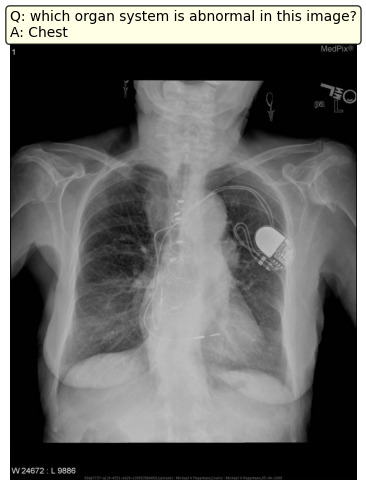


🩺 Câu trả lời: Chest


In [13]:
# ── Thay bằng ảnh thực tế của bạn ───────────────────────────
# Ví dụ 1: đường dẫn local
# IMAGE_PATH = '/kaggle/input/datasets/your_dataset/image.jpg'   # ← sửa tại đây

# Ví dụ 2: URL
IMAGE_PATH = 'https://datasets-server.huggingface.co/assets/flaviagiammarino/vqa-rad/--/default/train/2/image/image.jpg?Expires=1779190145&Signature=Vt2QXwPIJfsU4jj4leqao-D~G89A31KukqZ-rsxsqgbv3a4YsWz-bHCXvYjvnrVGtHYE-7B95zvWDQPdgu6Q8QBlTMrcvC4Q6usM6Vpc6fDM0zLm5JcD8AXFHoeJP4sODwgjiVFQyF8sFtaa1xJiqnyf6Kjb99YhrfLMc81jhoaY~yO0nMGNAukV3m9a~hUL2m-EHRq4ULUxj~0Og-aYklxLgqOsCN~mbKp7MBKOmFrCxV-waBsDoJqzKcinvfwtRcmjMRgpz54juHP46fK84emWXbCxltoWW9NmyxxI1Lhy9-htS98~ZTmjsPdbZnMCnOeSep8LTpUD7gbtCOj16g__&Key-Pair-Id=K204OQ5RWQVDLD'

QUESTION = 'which organ system is abnormal in this image?'   # ← câu hỏi của bạn

answer = predict(IMAGE_PATH, QUESTION)
print(f'\n🩺 Câu trả lời: {answer}')

🔄 Đang predict...
✅ Prediction: No
📥 Loading sentence transformer (lần đầu ~30s)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Câu hỏi     : are the kidneys visualized?
  Ground Truth: yes  [CLOSED]
  Prediction  : No
  Kết quả     : ❌ SAI
-------------------------------------------------------
  Exact Match        : 0      (1=khớp hoàn toàn)
  Token F1           : 0.0000  (0–1)
  BLEU-1             : 0.0000  (0–1)
  BLEU-4             : 0.0000  (0–1)
  ROUGE-L            : 0.0000  (0–1)
  Cosine Similarity  : 0.7335  (-1 đến 1, semantic)


/tmp/ipykernel_57/3711273656.py:144: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3711273656.py:145: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


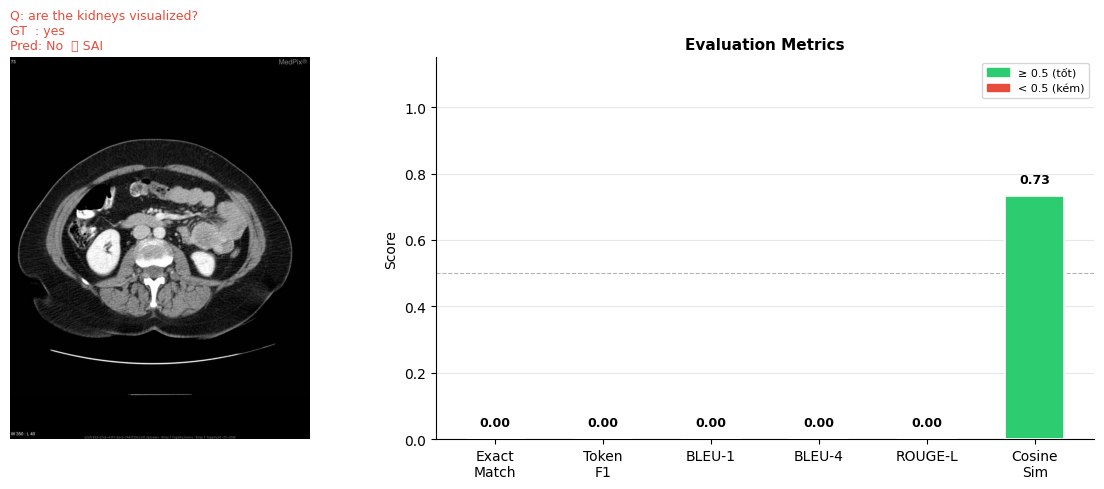

✅ Saved: single_eval.png


In [21]:
# ================================================================
#  ĐÁNH GIÁ 1 CÂU TRẢ LỜI VỚI GROUND TRUTH — nhập tay từ ngoài
# ================================================================
# Thay 3 dòng bên dưới, chạy cell là có kết quả đầy đủ.

IMAGE_PATH   = 'https://datasets-server.huggingface.co/cached-assets/flaviagiammarino/vqa-rad/--/bcf91e7654fb9d51c8ab6a5b82cacf3fafd2fae9/--/default/train/51/image/image.jpg?Expires=1779193642&Signature=mThCpELn62~MQ1D1QuWNi3U2P3HdEDxov~GcALv~EgZBJxg1Ef0MLeO-USo3jULksXNDdPG25sb6HuBDiRikyXVJ2qZ0uvZYdxYQpHDRkBVFRhVjh1-xEy-1mbr2cE9wMq2M42CrKY9hibV~vq9PNjh1pIotuImRJdoPvmknbu4iRHzG3XV8lDRbr10A~NCwOfZQSULlmNWZynDceVwgk9P~iAOcxfPX5JF~9qbz-SxINQcvLQNBeEflClPfPSqDsmpivO-0PSH8DFvBzNAjQPSOGoWQunAT~ueT1jD9ocNGSMUP72o5YgqdJMGOWTEtM4ZJhlpe4Depx9zWYuBBSw__&Key-Pair-Id=K204OQ5RWQVDLD'
QUESTION     = 'are the kidneys visualized?'   # ← câu hỏi
GROUND_TRUTH = 'yes'                                      # ← đáp án đúng

# ── Cài thêm nếu chưa có ────────────────────────────────────────
import subprocess, sys
for pkg in ['rouge-score', 'sentence-transformers', 'nltk']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import re, math, io
from collections import Counter
import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_scorer_lib
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos

# ── Load ảnh (URL hoặc local path) ──────────────────────────────
def load_image(src):
    if str(src).startswith('http'):
        resp = requests.get(src, timeout=15)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert('RGB')
    return Image.open(src).convert('RGB')

img = load_image(IMAGE_PATH)

# ── Predict ──────────────────────────────────────────────────────
print('🔄 Đang predict...')
prediction = predict(IMAGE_PATH, QUESTION, show_image=False, verbose=False)
print(f'✅ Prediction: {prediction}')

# ── Helper: normalize ────────────────────────────────────────────
def _norm(t):
    t = t.lower().strip()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# ── Metrics ──────────────────────────────────────────────────────
pred_n  = _norm(prediction)
gt_n    = _norm(GROUND_TRUTH)
pred_tok = pred_n.split()
gt_tok   = gt_n.split()

# 1. Exact Match
em = int(pred_n == gt_n)

# 2. Token F1
common   = Counter(pred_tok) & Counter(gt_tok)
n_common = sum(common.values())
if n_common == 0:
    f1 = 0.0
else:
    prec = n_common / len(pred_tok)
    rec  = n_common / len(gt_tok)
    f1   = 2 * prec * rec / (prec + rec)

# 3. BLEU-1
smoothie = SmoothingFunction().method1
bleu1 = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
bleu4 = sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie)

# 4. ROUGE-L
scorer = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = scorer.score(GROUND_TRUTH, prediction)['rougeL'].fmeasure

# 5. Cosine Similarity (semantic embedding)
print('📥 Loading sentence transformer (lần đầu ~30s)...')
_sim_model = SentenceTransformer('all-MiniLM-L6-v2')
emb_p = _sim_model.encode([prediction])
emb_g = _sim_model.encode([GROUND_TRUTH])
cosine = float(sk_cos(emb_p, emb_g)[0][0])

# 6. Q-type
q_type = 'CLOSED' if gt_n in ['yes', 'no'] else 'OPEN'
verdict = '✅ ĐÚNG' if em else '❌ SAI'

# ── In kết quả ───────────────────────────────────────────────────
print()
print('=' * 55)
print(f'  Câu hỏi     : {QUESTION}')
print(f'  Ground Truth: {GROUND_TRUTH}  [{q_type}]')
print(f'  Prediction  : {prediction}')
print(f'  Kết quả     : {verdict}')
print('-' * 55)
print(f'  Exact Match        : {em}      (1=khớp hoàn toàn)')
print(f'  Token F1           : {f1:.4f}  (0–1)')
print(f'  BLEU-1             : {bleu1:.4f}  (0–1)')
print(f'  BLEU-4             : {bleu4:.4f}  (0–1)')
print(f'  ROUGE-L            : {rouge_l:.4f}  (0–1)')
print(f'  Cosine Similarity  : {cosine:.4f}  (-1 đến 1, semantic)')
print('=' * 55)

# ── Visualize ────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.4]})

# --- Ảnh ---
ax_img.imshow(img, cmap='gray')
ax_img.axis('off')
border_color = '#2ecc71' if em else '#e74c3c'
for sp in ax_img.spines.values():
    sp.set_edgecolor(border_color); sp.set_linewidth(5); sp.set_visible(True)
ax_img.set_title(
    f'Q: {QUESTION}\n'
    f'GT  : {GROUND_TRUTH}\n'
    f'Pred: {prediction}  {verdict}',
    fontsize=9, loc='left', color=border_color, pad=6
)

# --- Bar chart metrics ---
metrics  = ['Exact\nMatch', 'Token\nF1', 'BLEU-1', 'BLEU-4', 'ROUGE-L', 'Cosine\nSim']
values   = [em, f1, bleu1, bleu4, rouge_l, cosine]
colors   = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in values]

bars = ax_bar.bar(metrics, values, color=colors, edgecolor='white', linewidth=1.2,
                  zorder=3, width=0.55)
ax_bar.set_ylim(0, 1.15)
ax_bar.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=2)
ax_bar.set_ylabel('Score', fontsize=10)
ax_bar.set_title('Evaluation Metrics', fontsize=11, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3, zorder=1)
ax_bar.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

good_p = mpatches.Patch(color='#2ecc71', label='≥ 0.5 (tốt)')
bad_p  = mpatches.Patch(color='#e74c3c', label='< 0.5 (kém)')
ax_bar.legend(handles=[good_p, bad_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: single_eval.png')


🔄 Đang predict...
✅ Prediction: CT
📥 Loading sentence transformer (lần đầu ~30s)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Câu hỏi     : what image modality is this?
  Ground Truth: ct  [OPEN]
  Prediction  : CT
  Kết quả     : ✅ ĐÚNG
-------------------------------------------------------
  Exact Match        : 1      (1=khớp hoàn toàn)
  Token F1           : 1.0000  (0–1)
  BLEU-1             : 1.0000  (0–1)
  BLEU-4             : 0.1778  (0–1)
  ROUGE-L            : 1.0000  (0–1)
  Cosine Similarity  : 1.0000  (-1 đến 1, semantic)


/tmp/ipykernel_57/37432304.py:144: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/37432304.py:145: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


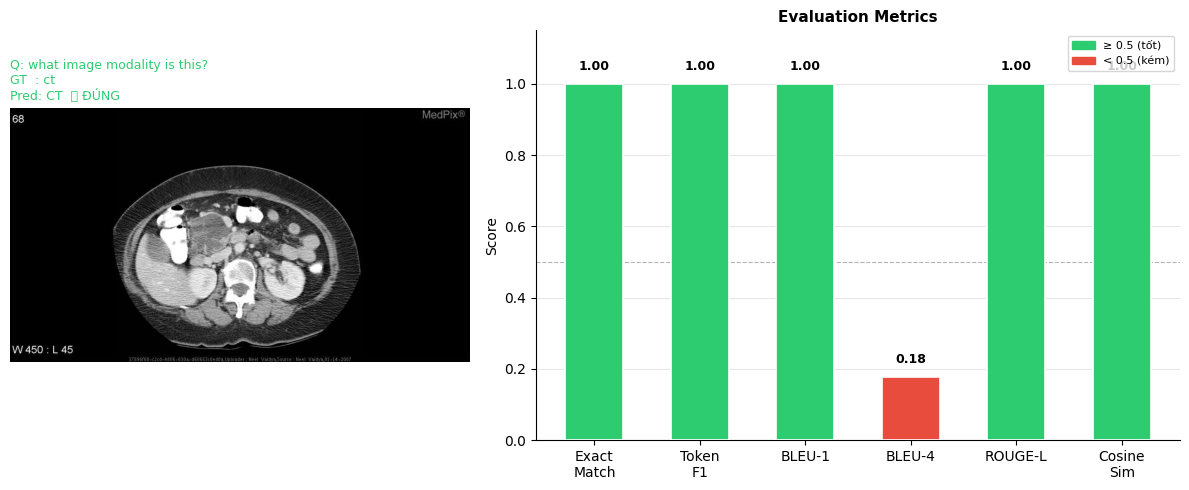

✅ Saved: single_eval.png


In [20]:
# ================================================================
#  ĐÁNH GIÁ 1 CÂU TRẢ LỜI VỚI GROUND TRUTH — nhập tay từ ngoài
# ================================================================
# Thay 3 dòng bên dưới, chạy cell là có kết quả đầy đủ.

IMAGE_PATH   = 'https://datasets-server.huggingface.co/cached-assets/flaviagiammarino/vqa-rad/--/bcf91e7654fb9d51c8ab6a5b82cacf3fafd2fae9/--/default/train/67/image/image.jpg?Expires=1779193642&Signature=WsgIFPoABA3TZkcw7OjrE~WWhS3HBkC8Bt1knn8D0~fjVJQKaXDQ3O90-cCwZDLj-zYybwmwkGPGqfDRxPk5Bmja0WN0tqC-i5UZeAq9XQyk5LfuCUmPuTLZNrt~fR4kBefKmR9Li6jin6DRLGtt1ZVFEV8XgPcRX8mun4USlOknu-Q38oJ5Psn4MONOdYFua4pDIhK8L07umqeXmcqoGHF82cqYlQ7Gyw1W6M25wHLYyri0v3WfLuQWyH9H~fRBg7MIjPejIbDeZCS-VAd49I5fYiED0wHNL9UmAgtBt44DSYRGxXjtBrAfAr0Kf1At7vaFDUzPBhaeg7JSeQjgMw__&Key-Pair-Id=K204OQ5RWQVDLD'
QUESTION     = 'what image modality is this?'   # ← câu hỏi
GROUND_TRUTH = 'ct'                                      # ← đáp án đúng

# ── Cài thêm nếu chưa có ────────────────────────────────────────
import subprocess, sys
for pkg in ['rouge-score', 'sentence-transformers', 'nltk']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import re, math, io
from collections import Counter
import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_scorer_lib
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos

# ── Load ảnh (URL hoặc local path) ──────────────────────────────
def load_image(src):
    if str(src).startswith('http'):
        resp = requests.get(src, timeout=15)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert('RGB')
    return Image.open(src).convert('RGB')

img = load_image(IMAGE_PATH)

# ── Predict ──────────────────────────────────────────────────────
print('🔄 Đang predict...')
prediction = predict(IMAGE_PATH, QUESTION, show_image=False, verbose=False)
print(f'✅ Prediction: {prediction}')

# ── Helper: normalize ────────────────────────────────────────────
def _norm(t):
    t = t.lower().strip()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# ── Metrics ──────────────────────────────────────────────────────
pred_n  = _norm(prediction)
gt_n    = _norm(GROUND_TRUTH)
pred_tok = pred_n.split()
gt_tok   = gt_n.split()

# 1. Exact Match
em = int(pred_n == gt_n)

# 2. Token F1
common   = Counter(pred_tok) & Counter(gt_tok)
n_common = sum(common.values())
if n_common == 0:
    f1 = 0.0
else:
    prec = n_common / len(pred_tok)
    rec  = n_common / len(gt_tok)
    f1   = 2 * prec * rec / (prec + rec)

# 3. BLEU-1
smoothie = SmoothingFunction().method1
bleu1 = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
bleu4 = sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie)

# 4. ROUGE-L
scorer = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = scorer.score(GROUND_TRUTH, prediction)['rougeL'].fmeasure

# 5. Cosine Similarity (semantic embedding)
print('📥 Loading sentence transformer (lần đầu ~30s)...')
_sim_model = SentenceTransformer('all-MiniLM-L6-v2')
emb_p = _sim_model.encode([prediction])
emb_g = _sim_model.encode([GROUND_TRUTH])
cosine = float(sk_cos(emb_p, emb_g)[0][0])

# 6. Q-type
q_type = 'CLOSED' if gt_n in ['yes', 'no'] else 'OPEN'
verdict = '✅ ĐÚNG' if em else '❌ SAI'

# ── In kết quả ───────────────────────────────────────────────────
print()
print('=' * 55)
print(f'  Câu hỏi     : {QUESTION}')
print(f'  Ground Truth: {GROUND_TRUTH}  [{q_type}]')
print(f'  Prediction  : {prediction}')
print(f'  Kết quả     : {verdict}')
print('-' * 55)
print(f'  Exact Match        : {em}      (1=khớp hoàn toàn)')
print(f'  Token F1           : {f1:.4f}  (0–1)')
print(f'  BLEU-1             : {bleu1:.4f}  (0–1)')
print(f'  BLEU-4             : {bleu4:.4f}  (0–1)')
print(f'  ROUGE-L            : {rouge_l:.4f}  (0–1)')
print(f'  Cosine Similarity  : {cosine:.4f}  (-1 đến 1, semantic)')
print('=' * 55)

# ── Visualize ────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.4]})

# --- Ảnh ---
ax_img.imshow(img, cmap='gray')
ax_img.axis('off')
border_color = '#2ecc71' if em else '#e74c3c'
for sp in ax_img.spines.values():
    sp.set_edgecolor(border_color); sp.set_linewidth(5); sp.set_visible(True)
ax_img.set_title(
    f'Q: {QUESTION}\n'
    f'GT  : {GROUND_TRUTH}\n'
    f'Pred: {prediction}  {verdict}',
    fontsize=9, loc='left', color=border_color, pad=6
)

# --- Bar chart metrics ---
metrics  = ['Exact\nMatch', 'Token\nF1', 'BLEU-1', 'BLEU-4', 'ROUGE-L', 'Cosine\nSim']
values   = [em, f1, bleu1, bleu4, rouge_l, cosine]
colors   = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in values]

bars = ax_bar.bar(metrics, values, color=colors, edgecolor='white', linewidth=1.2,
                  zorder=3, width=0.55)
ax_bar.set_ylim(0, 1.15)
ax_bar.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=2)
ax_bar.set_ylabel('Score', fontsize=10)
ax_bar.set_title('Evaluation Metrics', fontsize=11, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3, zorder=1)
ax_bar.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

good_p = mpatches.Patch(color='#2ecc71', label='≥ 0.5 (tốt)')
bad_p  = mpatches.Patch(color='#e74c3c', label='< 0.5 (kém)')
ax_bar.legend(handles=[good_p, bad_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: single_eval.png')


## 📋 Cell 8: Hỏi nhiều câu về cùng 1 ảnh

In [ ]:
IMAGE_PATH = '/kaggle/input/datasets/your_dataset/your_image.jpg'   # ← sửa tại đây

questions = [
    # 1. Nhóm câu hỏi dạng Yes/No (Phát hiện dấu hiệu)
    'Is there evidence of intracranial hemorrhage?',
    'Does the image show any mass effect or midline shift?',
    'Are the ventricles normal in size?',
    'Is there any sign of acute infarction?',

    # 2. Nhóm câu hỏi về Vị trí (Localization)
    'Which lobe of the brain is the lesion located in?',
    'Is the abnormality in the left or right hemisphere?',
    'Where is the tumor situated?',

    # 3. Nhóm câu hỏi về Đặc điểm hình ảnh & Phân loại
    'What type of hemorrhage is shown in this scan?',
    'Is the lesion hyperdense or hypodense?',
    'What imaging modality is used for this brain scan?',
    'Is this a T1-weighted or T2-weighted MRI?',

    # 4. Nhóm câu hỏi Đánh giá tổng quát
    'What is the most likely diagnosis based on this image?',
    'Are there multiple lesions or a single lesion?'
]

# Preprocess ảnh 1 lần, dùng lại cho nhiều câu hỏi
pixel_values, img_pil = preprocess_image(IMAGE_PATH)
print(f'🖼️  Ảnh: {img_pil.size} → BiomedCLIP transform applied')
print('=' * 60)

# Truyền PIL image trực tiếp (predict() nhận cả PIL.Image)
for q in questions:
    ans = predict(img_pil, q, show_image=False, verbose=False)
    print(f'Q: {q}')
    print(f'A: {ans}')
    print('-' * 40)

## 📁 Cell 9: Batch predict từ folder ảnh

In [ ]:
import os
import pandas as pd
from tqdm.auto import tqdm

IMAGE_FOLDER     = '/path/to/your/images/'    # ← sửa tại đây
DEFAULT_QUESTION = 'What abnormality is present in the image?'

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

image_files = [
    f for f in Path(IMAGE_FOLDER).iterdir()
    if f.suffix.lower() in SUPPORTED_EXTS
]

print(f'📂 Tìm thấy {len(image_files)} ảnh trong {IMAGE_FOLDER}')

results = []
for img_path in tqdm(image_files, desc='Predicting'):
    try:
        ans = predict(str(img_path), DEFAULT_QUESTION, show_image=False, verbose=False)
        results.append({'filename': img_path.name, 'question': DEFAULT_QUESTION, 'answer': ans, 'error': None})
    except Exception as e:
        results.append({'filename': img_path.name, 'question': DEFAULT_QUESTION, 'answer': None, 'error': str(e)})

df = pd.DataFrame(results)
print(f'\n✅ Kết quả:')
print(df.to_string(index=False))

output_csv = 'predictions.csv'
df.to_csv(output_csv, index=False)
print(f'\n💾 Đã lưu kết quả → {output_csv}')

## 📊 Cell 10: Evaluate trên tập test (nếu có ground truth)

In [12]:
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Metrics helpers ──────────────────────────────────────────
def normalize(s):
    return re.sub(r'[^a-z0-9 ]', '', str(s).lower().strip())

def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g:
        return 0.0
    n = sum((Counter(p) & Counter(g)).values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(g)
    return 2 * prec * rec / (prec + rec)

# ── Load dataset test ────────────────────────────────────────
print(f'📥 Loading test set từ {DATASET_NAME}...')
raw_ds    = load_dataset(DATASET_NAME)
test_data = raw_ds[TEST_SPLIT]

# Limit để test nhanh — bỏ [:50] để chạy toàn bộ
N_EVAL    = 50
test_data = test_data.select(range(min(N_EVAL, len(test_data))))
print(f'Evaluate trên {len(test_data)} samples...')

# ── Run evaluation ───────────────────────────────────────────
preds, gts, q_types = [], [], []

for item in tqdm(test_data, desc='Evaluating'):
    ans = predict(item['image'], str(item[Q_COL]), show_image=False, verbose=False)
    preds.append(ans)
    gts.append(str(item[A_COL]))
    q_types.append('CLOSED' if str(item[A_COL]).lower() in ['yes', 'no'] else 'OPEN')

# ── Tính metrics ─────────────────────────────────────────────
f1s  = [token_f1(p, g) for p, g in zip(preds, gts)]
accs = [int(normalize(p) == normalize(g)) for p, g in zip(preds, gts)]

overall_f1  = sum(f1s)  / len(f1s)  * 100
overall_acc = sum(accs) / len(accs) * 100

closed_idx = [i for i, t in enumerate(q_types) if t == 'CLOSED']
open_idx   = [i for i, t in enumerate(q_types) if t == 'OPEN']

def avg(lst, idx=None):
    subset = [lst[i] for i in idx] if idx else lst
    return sum(subset) / max(len(subset), 1) * 100

print(f'\n📊 Kết quả Evaluate ({len(preds)} samples):')
print(f'   Overall   — F1: {overall_f1:.2f}%  |  Acc: {overall_acc:.2f}%')
if closed_idx:
    print(f'   Closed Q  — F1: {avg(f1s,closed_idx):.2f}%  |  Acc: {avg(accs,closed_idx):.2f}%  ({len(closed_idx)} samples)')
if open_idx:
    print(f'   Open Q    — F1: {avg(f1s,open_idx):.2f}%  |  Acc: {avg(accs,open_idx):.2f}%  ({len(open_idx)} samples)')

# ── Hiện một số ví dụ sai ───────────────────────────────────
print('\n🔍 Ví dụ sai (F1 < 0.5):')
wrong = [(test_data[i][Q_COL], gts[i], preds[i], f1s[i])
         for i in range(len(preds)) if f1s[i] < 0.5]
for q, gt, pred, f1 in wrong[:5]:
    print(f'   Q    : {q}')
    print(f'   GT   : {gt}')
    print(f'   Pred : {pred}  (F1={f1:.3f})')
    print()

📥 Loading test set từ flaviagiammarino/vqa-rad...
Evaluate trên 50 samples...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


📊 Kết quả Evaluate (50 samples):
   Overall   — F1: 52.00%  |  Acc: 50.00%
   Closed Q  — F1: 65.62%  |  Acc: 65.62%  (32 samples)
   Open Q    — F1: 27.78%  |  Acc: 22.22%  (18 samples)

🔍 Ví dụ sai (F1 < 0.5):
   Q    : is there evidence of an aortic aneurysm?
   GT   : yes
   Pred : No  (F1=0.000)

   Q    : is there any intraparenchymal abnormalities in the lung fields?
   GT   : no
   Pred : Yes  (F1=0.000)

   Q    : where are the kidney?
   GT   : not seen here
   Pred : Lower Left  (F1=0.000)

   Q    : is the colon more prominent on the patient's right or left side?
   GT   : left
   Pred : Right  (F1=0.000)

   Q    : where is the colon most prominent from this view?
   GT   : left
   Pred : Upper right  (F1=0.000)



## 🎨 Cell 11: Full Evaluate + Visualize 5 samples ngẫu nhiên

In [ ]:
!pip install rouge-score sentence-transformers -q
print('✅ Xong!')

📥 Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded!
--- 5 mẫu ngẫu nhiên ---
[0] [OPEN] Q: size of the mass in the right upper quadrant?
      GT  : 3.4 cm
      Pred: 2.5
      EM=❌ | F1=0.000 | BLEU1=0.000 | ROUGE-L=0.000

[1] [OPEN] Q: is this an axial or saggital view of the brain?
      GT  : axial
      Pred: Axial
      EM=✅ | F1=1.000 | BLEU1=1.000 | ROUGE-L=1.000

[2] [OPEN] Q: what two tributaries of blood vessels are impacted?
      GT  : left aca and mca
      Pred: Arteries
      EM=❌ | F1=0.000 | BLEU1=0.000 | ROUGE-L=0.000

[3] [CLOSED] Q: are these normal kidney findings?
      GT  : no
      Pred: Yes
      EM=❌ | F1=0.000 | BLEU1=0.000 | ROUGE-L=0.000

[4] [OPEN] Q: what lobe is the lesion located in?
      GT  : right temporal lobe
      Pred: Right
      EM=❌ | F1=0.500 | BLEU1=0.135 | ROUGE-L=0.500

🔍 Tính Cosine Similarity cho 5 mẫu...
  [0] Cosine Sim: 0.503
  [1] Cosine Sim: 1.000
  [2] Cosine Sim: 0.087
  [3] Cosine Sim: 0.733
  [4] Cosine Sim: 0.249


/tmp/ipykernel_57/2930273579.py:77: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2930273579.py:77: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2930273579.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_57/2930273579.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.c

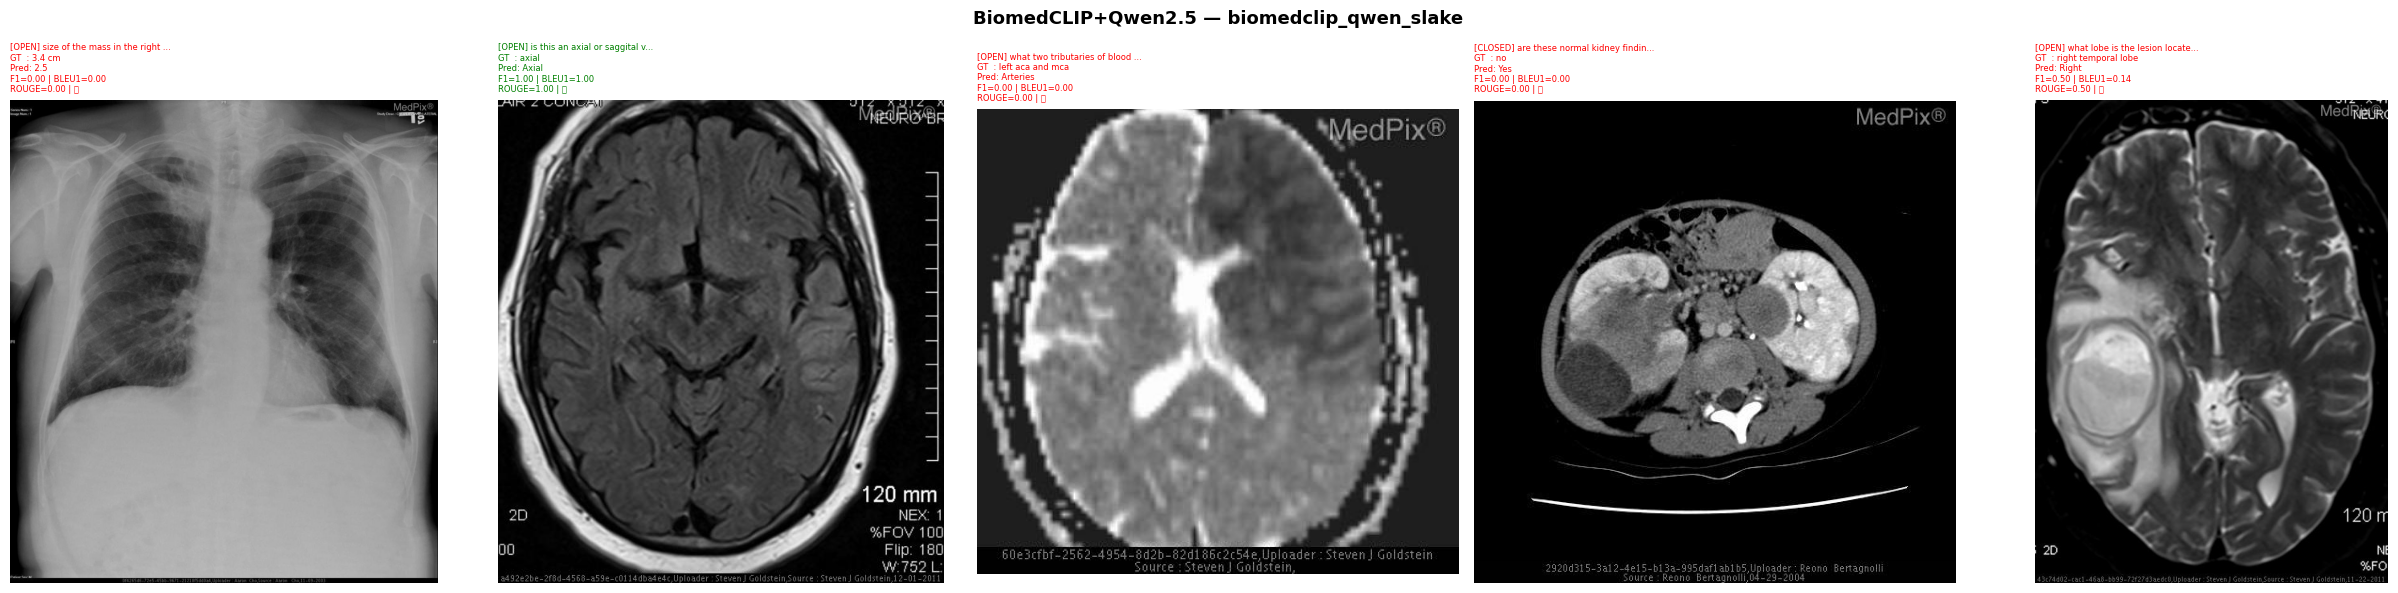


✅ Saved: random_samples.png


In [13]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Load model cosine similarity
print('📥 Loading sentence transformer...')
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Loaded!')

def cosine_sim_batch(preds, gts):
    pred_emb = sim_model.encode(preds, convert_to_numpy=True)
    gt_emb   = sim_model.encode(gts,   convert_to_numpy=True)
    return [float(cos_sim([p], [g])[0][0]) for p, g in zip(pred_emb, gt_emb)]

smoothie = SmoothingFunction().method1
rouge    = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# ── Visualize 5 samples ngẫu nhiên ──────────────────────────
sample_ids = random.sample(range(len(raw_ds[TEST_SPLIT])), 5)
fig, axes  = plt.subplots(1, 5, figsize=(25, 6))
print('--- 5 mẫu ngẫu nhiên ---')

sample_preds, sample_gts = [], []

for idx, sid in enumerate(sample_ids):
    item   = raw_ds[TEST_SPLIT][sid]
    q      = str(item[Q_COL])
    gt     = str(item[A_COL])
    pred   = predict(item['image'], q, show_image=False, verbose=False)
    qtype  = 'CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN'

    pred_tok = normalize(pred).split()
    gt_tok   = normalize(gt).split()
    f1       = token_f1(pred, gt)
    em       = int(normalize(pred) == normalize(gt))
    bleu1    = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
    rouge_l  = rouge.score(gt, pred)['rougeL'].fmeasure

    sample_preds.append(pred)
    sample_gts.append(gt)

    ax    = axes[idx]
    ax.imshow(item['image'], cmap='gray')
    ax.axis('off')
    color = 'green' if em else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    q_short = q[:30] + '...' if len(q) > 30 else q
    ax.set_title(
        f'[{qtype}] {q_short}\n'
        f'GT  : {gt}\n'
        f'Pred: {pred}\n'
        f'F1={f1:.2f} | BLEU1={bleu1:.2f}\n'
        f'ROUGE={rouge_l:.2f} | {"✅" if em else "❌"}',
        fontsize=6, loc='left', color=color
    )

    print(f'[{idx}] [{qtype}] Q: {q}')
    print(f'      GT  : {gt}')
    print(f'      Pred: {pred}')
    print(f'      EM={"✅" if em else "❌"} | F1={f1:.3f} | BLEU1={bleu1:.3f} | ROUGE-L={rouge_l:.3f}')
    print()

print('🔍 Tính Cosine Similarity cho 5 mẫu...')
sample_cosine = cosine_sim_batch(sample_preds, sample_gts)
for idx, cs in enumerate(sample_cosine):
    print(f'  [{idx}] Cosine Sim: {cs:.3f}')

plt.suptitle(f'BiomedCLIP+Qwen2.5 — {EXPERIMENT_NAME}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: random_samples.png')

## 📈 Cell 12: Full Evaluation trên toàn bộ test set

In [10]:
from datasets import load_dataset

print(f'📥 Loading {DATASET_NAME}...')
raw_ds = load_dataset(DATASET_NAME)
print(raw_ds)

# Xem thử 1 sample
s = raw_ds[TRAIN_SPLIT][0]
print(f'\nSample[0]:')
print(f'  Q    : {s[Q_COL]}')
print(f'  A    : {s[A_COL]}')
print(f'  img  : {s["image"].size}')

# SLAKE có thêm cột q_type: OPEN / CLOSED
if 'q_type' in s:
    print(f'  type : {s["q_type"]}')

print(f'\nTrain : {len(raw_ds[TRAIN_SPLIT])} | Test : {len(raw_ds[TEST_SPLIT])}')

# Thống kê Open vs Closed
if 'q_type' in raw_ds[TRAIN_SPLIT][0]:
    from collections import Counter
    types = Counter(raw_ds[TRAIN_SPLIT]['q_type'])
    print(f'Train q_type: {dict(types)}')

# ---- Dùng thẳng train / test — giống PaliGemma, không tách val ----
train_data = raw_ds[TRAIN_SPLIT]
test_data  = raw_ds[TEST_SPLIT]

# ---- Debug / Fast Test Mode ----
if DEBUG_MODE:
    train_data = train_data.select(range(min(DEBUG_TRAIN_SIZE, len(train_data))))
    test_data  = test_data.select(range(min(DEBUG_TEST_SIZE,  len(test_data))))
    print(f'\n⚡ DEBUG MODE: train={len(train_data)} | test={len(test_data)}')
    print('  (Đổi DEBUG_MODE = False trong Config để train toàn bộ)')
else:
    print(f'\n✅ Full dataset mode: train={len(train_data)} | test={len(test_data)}')

📥 Loading flaviagiammarino/vqa-rad...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1793
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 451
    })
})

Sample[0]:
  Q    : are regions of the brain infarcted?
  A    : yes
  img  : (566, 555)

Train : 1793 | Test : 451


NameError: name 'DEBUG_MODE' is not defined

In [14]:
model.eval()
all_preds, all_gts, all_qs, all_qtypes = [], [], [], []

# Load dataset nếu chưa có
if 'raw_ds' not in dir():
    raw_ds = load_dataset(DATASET_NAME)

for item in tqdm(raw_ds[TEST_SPLIT], desc='Full Eval'):
    q    = str(item[Q_COL])
    gt   = str(item[A_COL])
    pred = predict(item['image'], q, show_image=False, verbose=False)
    all_preds.append(pred)
    all_gts.append(gt)
    all_qs.append(q)
    all_qtypes.append('CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN')

# ── Tính đầy đủ metrics ──────────────────────────────────────
f1s, accs, bleu1s, bleu4s, rougels = [], [], [], [], []
for pred, gt in zip(all_preds, all_gts):
    pred_tok = normalize(pred).split()
    gt_tok   = normalize(gt).split()
    f1s.append(token_f1(pred, gt))
    accs.append(int(normalize(pred) == normalize(gt)))
    bleu1s.append(sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie))
    bleu4s.append(sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie))
    rougels.append(rouge.score(gt, pred)['rougeL'].fmeasure)

print('🔍 Tính Cosine Similarity...')
cosine_scores = cosine_sim_batch(all_preds, all_gts)

ci = [i for i, t in enumerate(all_qtypes) if t == 'CLOSED']
oi = [i for i, t in enumerate(all_qtypes) if t == 'OPEN']

def avg(lst, idx=None):
    subset = [lst[i] for i in idx] if idx else lst
    return sum(subset) / max(len(subset), 1) * 100

print('\n' + '='*60)
print('📊 BIOMEDCLIP + QWEN2.5 FULL RESULTS')
print('='*60)
print(f'{"Metric":<22} {"Overall":>10} {"Closed":>10} {"Open":>10}')
print('-'*60)
print(f'{"Exact Match":<22} {avg(accs):>9.2f}% {avg(accs,ci):>9.2f}% {avg(accs,oi):>9.2f}%')
print(f'{"Token F1":<22} {avg(f1s):>9.2f}% {avg(f1s,ci):>9.2f}% {avg(f1s,oi):>9.2f}%')
print(f'{"BLEU-1":<22} {avg(bleu1s):>9.2f}% {avg(bleu1s,ci):>9.2f}% {avg(bleu1s,oi):>9.2f}%')
print(f'{"BLEU-4":<22} {avg(bleu4s):>9.2f}% {avg(bleu4s,ci):>9.2f}% {avg(bleu4s,oi):>9.2f}%')
print(f'{"ROUGE-L":<22} {avg(rougels):>9.2f}% {avg(rougels,ci):>9.2f}% {avg(rougels,oi):>9.2f}%')
print(f'{"Cosine Sim":<22} {avg(cosine_scores):>9.2f}% {avg(cosine_scores,ci):>9.2f}% {avg(cosine_scores,oi):>9.2f}%')
print('='*60)
print(f'  n_total={len(all_preds)} | n_closed={len(ci)} | n_open={len(oi)}')

# ── Lưu CSV ─────────────────────────────────────────────────
df = pd.DataFrame({
    'question'    : all_qs,
    'prediction'  : all_preds,
    'ground_truth': all_gts,
    'q_type'      : all_qtypes,
    'exact_match' : accs,
    'token_f1'    : f1s,
    'bleu1'       : bleu1s,
    'bleu4'       : bleu4s,
    'rouge_l'     : rougels,
    'cosine_sim'  : cosine_scores
})
out_csv = f'{EXPERIMENT_NAME}_predictions.csv'
df.to_csv(out_csv, index=False)
print(f'\n✅ Saved: {out_csv} ({len(df)} rows)')

Full Eval:   0%|          | 0/451 [00:00<?, ?it/s]

🔍 Tính Cosine Similarity...

📊 BIOMEDCLIP + QWEN2.5 FULL RESULTS
Metric                    Overall     Closed       Open
------------------------------------------------------------
Exact Match                35.48%     54.18%     12.00%
Token F1                   38.08%     54.18%     17.87%
BLEU-1                     36.76%     54.18%     14.90%
BLEU-4                      6.66%      9.64%      2.92%
ROUGE-L                    38.14%     54.18%     18.00%
Cosine Sim                 66.97%     87.26%     41.52%
  n_total=451 | n_closed=251 | n_open=200

✅ Saved: biomedclip_qwen_slake_predictions.csv (451 rows)


In [13]:
# ================================================================
#  CELL 13: GIAO DIỆN DEMO TƯƠNG TÁC — BiomedCLIP + Qwen2.5 VQA
#  Yêu cầu: chạy Cell 5 trước để load model vào biến `model`
# ================================================================

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gradio'], check=False)

import gradio as gr
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import re
from collections import Counter


# ── Metric helpers ───────────────────────────────────────────────
def _norm(t):
    t = str(t).lower().strip()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

def token_f1(pred, gt):
    p_tok = _norm(pred).split()
    g_tok = _norm(gt).split()
    if not p_tok or not g_tok:
        return 0.0
    n = sum((Counter(p_tok) & Counter(g_tok)).values())
    if n == 0:
        return 0.0
    prec = n / len(p_tok)
    rec  = n / len(g_tok)
    return 2 * prec * rec / (prec + rec)


# ── Hàm predict chính ────────────────────────────────────────────
def run_inference(image: Image.Image, question: str, ground_truth: str):
    """
    Gradio callback:
      - image        : PIL.Image từ gr.Image
      - question     : câu hỏi (str)
      - ground_truth : đáp án đúng (str, có thể rỗng)
    Returns:
      - answer_text  : str
      - metrics_plot : matplotlib figure (PNG)
    """
    if image is None:
        return '⚠️ Hãy upload ảnh trước.', None
    if not question.strip():
        return '⚠️ Hãy nhập câu hỏi.', None

    # ── Predict ──────────────────────────────────────────────────
    try:
        answer = predict(image, question, show_image=False, verbose=False)
    except Exception as e:
        return f'❌ Lỗi khi predict: {e}', None

    result_text = f'🩺 **Câu trả lời:** {answer}'

    # ── Nếu có ground truth → tính metrics ───────────────────────
    fig = None
    if ground_truth.strip():
        gt = ground_truth.strip()
        em = int(_norm(answer) == _norm(gt))
        f1 = token_f1(answer, gt)

        try:
            import nltk
            nltk.download('punkt', quiet=True)
            nltk.download('punkt_tab', quiet=True)
            from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
            smoothie  = SmoothingFunction().method1
            pred_tok  = _norm(answer).split()
            gt_tok    = _norm(gt).split()
            bleu1 = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
            bleu4 = sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie)
        except Exception:
            bleu1 = bleu4 = 0.0

        try:
            from rouge_score import rouge_scorer as rs_lib
            rouge_l = rs_lib.RougeScorer(['rougeL'], use_stemmer=True).score(gt, answer)['rougeL'].fmeasure
        except Exception:
            rouge_l = 0.0

        q_type  = 'CLOSED' if _norm(gt) in ['yes', 'no'] else 'OPEN'
        verdict = '✅ ĐÚNG' if em else '❌ SAI'
        result_text = (
            f'🩺 **Câu trả lời:** {answer}\n\n'
            f'📋 **Ground Truth:** {gt}  [{q_type}]\n\n'
            f'**Kết quả:** {verdict}\n\n'
            f'| Metric | Score |\n'
            f'|--------|-------|\n'
            f'| Exact Match | {em} |\n'
            f'| Token F1 | {f1:.4f} |\n'
            f'| BLEU-1 | {bleu1:.4f} |\n'
            f'| BLEU-4 | {bleu4:.4f} |\n'
            f'| ROUGE-L | {rouge_l:.4f} |\n'
        )

        # ── Bar chart metrics ─────────────────────────────────────
        metrics = ['Exact\nMatch', 'Token\nF1', 'BLEU-1', 'BLEU-4', 'ROUGE-L']
        values  = [em, f1, bleu1, bleu4, rouge_l]
        colors  = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in values]

        fig, ax = plt.subplots(figsize=(7, 4))
        bars = ax.bar(metrics, values, color=colors, edgecolor='white',
                      linewidth=1.2, zorder=3, width=0.55)
        ax.set_ylim(0, 1.2)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=2)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_title(
            f'Evaluation Metrics  |  GT: "{gt}"  →  Pred: "{answer}"  {verdict}',
            fontsize=9, pad=8
        )
        ax.grid(axis='y', alpha=0.3, zorder=1)
        ax.spines[['top', 'right']].set_visible(False)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.04,
                    f'{val:.2f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
        good_p = mpatches.Patch(color='#2ecc71', label='≥ 0.5 (tốt)')
        bad_p  = mpatches.Patch(color='#e74c3c', label='< 0.5 (kém)')
        ax.legend(handles=[good_p, bad_p], fontsize=9, loc='upper right')
        plt.tight_layout()

    return result_text, fig


# ── Danh sách câu hỏi mẫu (dropdown gợi ý) ───────────────────────
SAMPLE_QUESTIONS = [
    'Are the lungs normal appearing?',
    'Is there evidence of pneumonia?',
    'What organ is shown in this image?',
    'Is there pleural effusion?',
    'What image modality is this?',
    'Is there any abnormality present?',
    'Where is the lesion located?',
    'Is this a T1-weighted or T2-weighted MRI?',
    'Are the kidneys visualized?',
    'What is the most likely diagnosis?',
]


# ── Xây dựng Gradio UI ───────────────────────────────────────────
with gr.Blocks(
    title='BiomedCLIP + Qwen2.5 Medical VQA Demo',
    theme=gr.themes.Soft(primary_hue='blue'),
) as demo:

    gr.Markdown(
        '# 🩺 BiomedCLIP + Qwen2.5 — Medical VQA Demo\n'
        'Upload ảnh y tế, nhập câu hỏi và nhận câu trả lời từ mô hình đã fine-tune.'
    )

    with gr.Row():
        # ── Cột trái: input ──────────────────────────────────────
        with gr.Column(scale=1):
            img_input = gr.Image(
                type='pil',
                label='📤 Upload ảnh y tế (X-ray / CT / MRI)',
                height=300,
            )

            question_input = gr.Textbox(
                label='❓ Câu hỏi (tiếng Anh)',
                placeholder='Ví dụ: Are the lungs normal appearing?',
                lines=2,
            )

            # Dropdown gợi ý câu hỏi
            sample_dd = gr.Dropdown(
                choices=SAMPLE_QUESTIONS,
                label='💡 Gợi ý câu hỏi (chọn để điền tự động)',
                interactive=True,
                value=None,
            )
            sample_dd.change(
                fn=lambda q: q,
                inputs=sample_dd,
                outputs=question_input,
            )

            gt_input = gr.Textbox(
                label='📋 Ground Truth (tuỳ chọn — để đánh giá metrics)',
                placeholder='Ví dụ: yes  /  no  /  chest  /  pneumonia ...',
                lines=1,
            )

            predict_btn = gr.Button('🔍  Predict', variant='primary', size='lg')
            clear_btn   = gr.Button('🗑️  Xóa', variant='secondary', size='sm')

        # ── Cột phải: output ─────────────────────────────────────
        with gr.Column(scale=1):
            answer_out  = gr.Markdown(label='Kết quả')
            metrics_out = gr.Plot(
                label='📊 Metrics (hiển thị khi có Ground Truth)',
            )

    # ── Examples tích hợp sẵn ────────────────────────────────────
    gr.Markdown('---\n### 📌 Hướng dẫn nhanh\n'
        '1. Upload ảnh y tế bất kỳ (JPEG / PNG)\n'
        '2. Nhập câu hỏi hoặc chọn từ dropdown *Gợi ý câu hỏi*\n'
        '3. (Tuỳ chọn) Nhập Ground Truth để xem đánh giá Exact Match, F1, BLEU, ROUGE-L\n'
        '4. Nhấn **Predict** và đợi vài giây\n'
    )

    # ── Wiring buttons ────────────────────────────────────────────
    predict_btn.click(
        fn=run_inference,
        inputs=[img_input, question_input, gt_input],
        outputs=[answer_out, metrics_out],
    )

    clear_btn.click(
        fn=lambda: (None, '', '', '', None),
        inputs=[],
        outputs=[img_input, question_input, gt_input, answer_out, metrics_out],
    )


# ── Khởi động server ─────────────────────────────────────────────
print('🚀 Khởi động Gradio demo...')
demo.launch(
    share=True,          # tạo link public (hữu ích trên Kaggle/Colab)
    server_name='0.0.0.0',
    server_port=None,
    debug=False,
    show_error=True,
)
print('✅ Demo đang chạy tại http://localhost:7860')


/tmp/ipykernel_57/1544715045.py:150: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


🚀 Khởi động Gradio demo...
* Running on local URL:  http://0.0.0.0:7861
* Running on public URL: https://e975bc31b07e0c52c5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Demo đang chạy tại http://localhost:7860


/tmp/ipykernel_57/1544715045.py:129: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:81: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(output_bytes, format=fmt)
